# GSE282203 — Visium Spatial Transcriptomics (Alzheimer's / Circadian)

This notebook assembles the GEO supplementary files from **GSE282203** into a combined AnnData object with full sample metadata.

**Study:** *Spatial transcriptomics identifies regional disruptions in brain rhythmic gene expression in a mouse model of Alzheimer's disease*

- **Platform:** 10x Visium (Illumina NovaSeq 6000)
- **Organism:** *Mus musculus*
- **Samples:** 65 sagittal brain sections
- **Design:** APP23 transgenic vs WT controls × 7 / 14 months × ZT0 / ZT6 / ZT12 / ZT18 × Male / Female

The notebook:
1. Reconstructs per-sample Space Ranger directory layouts from the GEO files.
2. Loads each sample with `scanpy.read_visium()` and attaches metadata (genotype, age, sex, zeitgeber time, replicate).
3. Concatenates all samples into a single AnnData.
4. Saves the combined `.h5ad`.

In [6]:
from __future__ import annotations

import gzip
import json
import os
import re
import shutil
from pathlib import Path

os.environ.setdefault("KMP_WARNINGS", "0")

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.io

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 60)

DATA_DIR = Path("../data/GSE282203")
CACHE_DIR = DATA_DIR / "spaceranger_cache"
OUTPUT_DIR = DATA_DIR
OUTPUT_PATH = OUTPUT_DIR / "GSE282203_combined.h5ad"

WRITE_OUTPUT = True

## Build sample metadata

Parse metadata from the GEO sample titles and map each GSM accession to its capture area ID (extracted from the filenames).

In [7]:
# Sample metadata from GEO series matrix
# Format: "Brain, {genotype}, {age}, {sex}, {zeitgeber_time}, rep{n}"
SAMPLE_METADATA = {
    "GSM8637961": ("APP23", "14 months", "Female", "ZT0", 1),
    "GSM8637962": ("APP23", "14 months", "Female", "ZT0", 2),
    "GSM8637963": ("APP23", "14 months", "Female", "ZT12", 1),
    "GSM8637964": ("APP23", "14 months", "Female", "ZT12", 2),
    "GSM8637965": ("APP23", "14 months", "Female", "ZT18", 1),
    "GSM8637966": ("APP23", "14 months", "Female", "ZT18", 2),
    "GSM8637967": ("APP23", "14 months", "Female", "ZT6", 1),
    "GSM8637968": ("APP23", "14 months", "Female", "ZT6", 2),
    "GSM8637969": ("APP23", "14 months", "Male", "ZT0", 1),
    "GSM8637970": ("APP23", "14 months", "Male", "ZT0", 2),
    "GSM8637971": ("APP23", "14 months", "Male", "ZT12", 1),
    "GSM8637972": ("APP23", "14 months", "Male", "ZT12", 2),
    "GSM8637973": ("APP23", "14 months", "Male", "ZT18", 1),
    "GSM8637974": ("APP23", "14 months", "Male", "ZT18", 2),
    "GSM8637975": ("APP23", "14 months", "Male", "ZT6", 1),
    "GSM8637976": ("APP23", "14 months", "Male", "ZT6", 2),
    "GSM8637977": ("APP23", "7 months", "Female", "ZT0", 1),
    "GSM8637978": ("APP23", "7 months", "Female", "ZT0", 2),
    "GSM8637979": ("APP23", "7 months", "Female", "ZT12", 1),
    "GSM8637980": ("APP23", "7 months", "Female", "ZT12", 2),
    "GSM8637981": ("APP23", "7 months", "Female", "ZT18", 1),
    "GSM8637982": ("APP23", "7 months", "Female", "ZT18", 2),
    "GSM8637983": ("APP23", "7 months", "Female", "ZT6", 1),
    "GSM8637984": ("APP23", "7 months", "Female", "ZT6", 2),
    "GSM8637985": ("APP23", "7 months", "Male", "ZT0", 1),
    "GSM8637986": ("APP23", "7 months", "Male", "ZT0", 2),
    "GSM8637987": ("APP23", "7 months", "Male", "ZT12", 1),
    "GSM8637988": ("APP23", "7 months", "Male", "ZT12", 2),
    "GSM8637989": ("APP23", "7 months", "Male", "ZT18", 1),
    "GSM8637990": ("APP23", "7 months", "Male", "ZT18", 2),
    "GSM8637991": ("APP23", "7 months", "Male", "ZT6", 1),
    "GSM8637992": ("APP23", "7 months", "Male", "ZT6", 2),
    "GSM8637993": ("WT", "14 months", "Female", "ZT0", 1),
    "GSM8637994": ("WT", "14 months", "Female", "ZT0", 2),
    "GSM8637995": ("WT", "14 months", "Female", "ZT12", 1),
    "GSM8637996": ("WT", "14 months", "Female", "ZT12", 2),
    "GSM8637997": ("WT", "14 months", "Female", "ZT18", 1),
    "GSM8637998": ("WT", "14 months", "Female", "ZT18", 2),
    "GSM8637999": ("WT", "14 months", "Female", "ZT18", 3),
    "GSM8638000": ("WT", "14 months", "Female", "ZT6", 1),
    "GSM8638001": ("WT", "14 months", "Female", "ZT6", 2),
    "GSM8638002": ("WT", "14 months", "Male", "ZT0", 1),
    "GSM8638003": ("WT", "14 months", "Male", "ZT12", 1),
    "GSM8638004": ("WT", "14 months", "Male", "ZT12", 2),
    "GSM8638005": ("WT", "14 months", "Male", "ZT18", 1),
    "GSM8638006": ("WT", "14 months", "Male", "ZT18", 2),
    "GSM8638007": ("WT", "14 months", "Male", "ZT6", 1),
    "GSM8638008": ("WT", "14 months", "Male", "ZT6", 2),
    "GSM8638009": ("WT", "7 months", "Female", "ZT0", 1),
    "GSM8638010": ("WT", "7 months", "Female", "ZT0", 2),
    "GSM8638011": ("WT", "7 months", "Female", "ZT12", 1),
    "GSM8638012": ("WT", "7 months", "Female", "ZT12", 2),
    "GSM8638013": ("WT", "7 months", "Female", "ZT12", 3),
    "GSM8638014": ("WT", "7 months", "Female", "ZT18", 1),
    "GSM8638015": ("WT", "7 months", "Female", "ZT18", 2),
    "GSM8638016": ("WT", "7 months", "Female", "ZT6", 1),
    "GSM8638017": ("WT", "7 months", "Female", "ZT6", 2),
    "GSM8638018": ("WT", "7 months", "Male", "ZT0", 1),
    "GSM8638019": ("WT", "7 months", "Male", "ZT0", 2),
    "GSM8638020": ("WT", "7 months", "Male", "ZT12", 1),
    "GSM8638021": ("WT", "7 months", "Male", "ZT12", 2),
    "GSM8638022": ("WT", "7 months", "Male", "ZT18", 1),
    "GSM8638023": ("WT", "7 months", "Male", "ZT18", 2),
    "GSM8638024": ("WT", "7 months", "Male", "ZT6", 1),
    "GSM8638025": ("WT", "7 months", "Male", "ZT6", 2),
}

metadata_df = pd.DataFrame.from_dict(
    SAMPLE_METADATA,
    orient="index",
    columns=["genotype", "age", "sex", "zeitgeber_time", "replicate"],
)
metadata_df.index.name = "gsm_id"
metadata_df["tissue"] = "Brain"
metadata_df["organism"] = "Mus musculus"

# Map GSM to capture area ID from filenames
gsm_to_capture = {}
for f in sorted(DATA_DIR.glob("GSM*_*_matrix.mtx.gz")):
    m = re.match(r"(GSM\d+)_(.+)_matrix\.mtx\.gz", f.name)
    if m:
        gsm_to_capture[m.group(1)] = m.group(2)

metadata_df["capture_area"] = metadata_df.index.map(gsm_to_capture)

print(f"Samples with metadata: {len(metadata_df)}")
print(f"Samples with capture area mapping: {metadata_df['capture_area'].notna().sum()}")
metadata_df.head(10)

Samples with metadata: 65
Samples with capture area mapping: 65


,genotype,age,sex,zeitgeber_time,replicate,tissue,organism,capture_area
gsm_id,,,,,,,,
GSM8637961,APP23,14 months,Female,ZT0,1,Brain,Mus musculus,040-A
GSM8637962,APP23,14 months,Female,ZT0,2,Brain,Mus musculus,043-A
GSM8637963,APP23,14 months,Female,ZT12,1,Brain,Mus musculus,030-C
GSM8637964,APP23,14 months,Female,ZT12,2,Brain,Mus musculus,040-C
GSM8637965,APP23,14 months,Female,ZT18,1,Brain,Mus musculus,030-D
GSM8637966,APP23,14 months,Female,ZT18,2,Brain,Mus musculus,040-D
GSM8637967,APP23,14 months,Female,ZT6,1,Brain,Mus musculus,030-B
GSM8637968,APP23,14 months,Female,ZT6,2,Brain,Mus musculus,040-B
GSM8637969,APP23,14 months,Male,ZT0,1,Brain,Mus musculus,109-A


## Reconstruct Space Ranger layouts

`scanpy.read_visium()` expects a standard Space Ranger output directory. For each sample, decompress the GEO files into the expected layout:

```
spaceranger_cache/{GSM_ID}/
    filtered_feature_bc_matrix/
        barcodes.tsv.gz
        features.tsv.gz
        matrix.mtx.gz
    spatial/
        scalefactors_json.json
        tissue_positions.csv
```

In [8]:
def _decompress_gz(src: Path, dst: Path) -> None:
    with gzip.open(src, "rb") as f_in, open(dst, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)


def setup_spaceranger_dir(gsm_id: str, capture_area: str) -> Path:
    """Reconstruct a Space Ranger-like directory from GEO files."""
    sample_dir = CACHE_DIR / gsm_id
    matrix_dir = sample_dir / "filtered_feature_bc_matrix"
    spatial_dir = sample_dir / "spatial"
    matrix_dir.mkdir(parents=True, exist_ok=True)
    spatial_dir.mkdir(parents=True, exist_ok=True)

    prefix = f"{gsm_id}_{capture_area}"

    # Matrix files — keep gzipped, scanpy reads them directly
    for src_name, dst_name in [
        (f"{prefix}_barcodes.tsv.gz", "barcodes.tsv.gz"),
        (f"{prefix}_features.tsv.gz", "features.tsv.gz"),
        (f"{prefix}_matrix.mtx.gz", "matrix.mtx.gz"),
    ]:
        dst = matrix_dir / dst_name
        if not dst.exists():
            shutil.copy2(DATA_DIR / src_name, dst)

    # Spatial files — decompress
    for src_name, dst_name in [
        (f"{prefix}_scalefactors_json.json.gz", "scalefactors_json.json"),
        (f"{prefix}_tissue_positions.csv.gz", "tissue_positions.csv"),
    ]:
        dst = spatial_dir / dst_name
        if not dst.exists():
            _decompress_gz(DATA_DIR / src_name, dst)

    return sample_dir


# Process all samples that have downloaded files
ready_samples = metadata_df[metadata_df["capture_area"].notna()].copy()
print(f"Setting up Space Ranger directories for {len(ready_samples)} samples...")

for gsm_id, row in ready_samples.iterrows():
    setup_spaceranger_dir(gsm_id, row["capture_area"])

print("Done.")

Setting up Space Ranger directories for 65 samples...
Done.


## Load samples and attach metadata

Load each sample with `scanpy.read_visium()`, attach per-spot metadata columns, and concatenate into a single AnnData.

In [9]:
adatas = {}
failed = []

for gsm_id, row in ready_samples.iterrows():
    sample_dir = CACHE_DIR / gsm_id
    try:
        # Load the count matrix from the MTX directory
        adata = sc.read_10x_mtx(sample_dir / "filtered_feature_bc_matrix")
        adata.var_names_make_unique()

        # Load spatial coordinates
        positions = pd.read_csv(
            sample_dir / "spatial" / "tissue_positions.csv",
            header=None if not (sample_dir / "spatial" / "tissue_positions.csv").read_text().startswith("barcode") else 0,
        )
        # Handle both header and no-header formats
        if positions.columns[0] == "barcode":
            positions = positions.set_index("barcode")
            positions.columns = ["in_tissue", "array_row", "array_col", "pxl_row_in_fullres", "pxl_col_in_fullres"]
        else:
            positions.columns = ["barcode", "in_tissue", "array_row", "array_col", "pxl_row_in_fullres", "pxl_col_in_fullres"]
            positions = positions.set_index("barcode")

        # Align to adata barcodes
        common = adata.obs_names.intersection(positions.index)
        adata = adata[common].copy()
        positions = positions.loc[common]

        adata.obs["in_tissue"] = positions["in_tissue"].values
        adata.obs["array_row"] = positions["array_row"].values
        adata.obs["array_col"] = positions["array_col"].values
        adata.obsm["spatial"] = positions[["pxl_row_in_fullres", "pxl_col_in_fullres"]].values

        # Load scale factors
        with open(sample_dir / "spatial" / "scalefactors_json.json") as f:
            scalefactors = json.load(f)
        adata.uns["spatial"] = {gsm_id: {"scalefactors": scalefactors}}

        # Attach metadata to every spot
        adata.obs["gsm_id"] = gsm_id
        adata.obs["capture_area"] = row["capture_area"]
        adata.obs["genotype"] = row["genotype"]
        adata.obs["age"] = row["age"]
        adata.obs["sex"] = row["sex"]
        adata.obs["zeitgeber_time"] = row["zeitgeber_time"]
        adata.obs["replicate"] = row["replicate"]
        adata.obs["tissue"] = "Brain"
        adata.obs["organism"] = "Mus musculus"

        for col in ["gsm_id", "capture_area", "genotype", "age", "sex", "zeitgeber_time"]:
            adata.obs[col] = adata.obs[col].astype("category")

        adatas[gsm_id] = adata
        print(f"  {gsm_id} ({row['capture_area']}): {adata.n_obs} spots x {adata.n_vars} genes")
    except Exception as e:
        failed.append(gsm_id)
        print(f"  {gsm_id} FAILED: {e}")

print(f"\nLoaded: {len(adatas)} / {len(ready_samples)} samples")
if failed:
    print(f"Failed: {failed}")

  GSM8637961 (040-A): 3499 spots x 32286 genes
  GSM8637962 (043-A): 3697 spots x 32286 genes
  GSM8637963 (030-C): 3584 spots x 32286 genes
  GSM8637964 (040-C): 3646 spots x 32286 genes
  GSM8637965 (030-D): 3552 spots x 32286 genes
  GSM8637966 (040-D): 3546 spots x 32286 genes
  GSM8637967 (030-B): 2980 spots x 32286 genes
  GSM8637968 (040-B): 3556 spots x 32286 genes
  GSM8637969 (109-A): 3540 spots x 32286 genes
  GSM8637970 (120-A): 3256 spots x 32286 genes
  GSM8637971 (109-C): 3672 spots x 32286 genes
  GSM8637972 (120-C): 3583 spots x 32286 genes
  GSM8637973 (109-D): 3613 spots x 32286 genes
  GSM8637974 (120-D): 3037 spots x 32286 genes
  GSM8637975 (120-B): 3709 spots x 32286 genes
  GSM8637976 (043-B): 3440 spots x 32286 genes
  GSM8637977 (106-A): 3559 spots x 32286 genes
  GSM8637978 (107-A): 3580 spots x 32286 genes
  GSM8637979 (106-C): 3559 spots x 32286 genes
  GSM8637980 (124-A): 3672 spots x 32286 genes
  GSM8637981 (107-D): 3579 spots x 32286 genes
  GSM8637982 

## Concatenate

In [11]:
adata_combined = ad.concat(
    adatas,
    label="sample",
    index_unique="-",
    join="outer",
)

# Store GEO accession in uns
adata_combined.uns["geo_accession"] = "GSE282203"
adata_combined.uns["study_title"] = (
    "Spatial transcriptomics identifies regional disruptions in brain "
    "rhythmic gene expression in a mouse model of Alzheimer's disease"
)
adata_combined.uns["platform"] = "10x Visium"

print(adata_combined)
print(f"\nMetadata columns: {list(adata_combined.obs.columns)}")
print(f"\nSamples per genotype:\n{adata_combined.obs.groupby('genotype')['gsm_id'].nunique()}")
print(f"\nSamples per age:\n{adata_combined.obs.groupby('age')['gsm_id'].nunique()}")

AnnData object with n_obs × n_vars = 232326 × 32286
    obs: 'in_tissue', 'array_row', 'array_col', 'gsm_id', 'capture_area', 'genotype', 'age', 'sex', 'zeitgeber_time', 'replicate', 'tissue', 'organism', 'sample'
    uns: 'geo_accession', 'study_title', 'platform'
    obsm: 'spatial'

Metadata columns: ['in_tissue', 'array_row', 'array_col', 'gsm_id', 'capture_area', 'genotype', 'age', 'sex', 'zeitgeber_time', 'replicate', 'tissue', 'organism', 'sample']

Samples per genotype:
genotype
APP23    32
WT       33
Name: gsm_id, dtype: int64

Samples per age:
age
7 months     33
14 months    32
Name: gsm_id, dtype: int64


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_1442/1926823208.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(f"\nSamples per genotype:\n{adata_combined.obs.groupby('genotype')['gsm_id'].nunique()}")
/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_1442/1926823208.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(f"\nSamples per age:\n{adata_combined.obs.groupby('age')['gsm_id'].nunique()}")


In [12]:
# Summary of experimental design
summary = (
    adata_combined.obs
    .groupby(["genotype", "age", "sex", "zeitgeber_time"])["gsm_id"]
    .nunique()
    .reset_index(name="n_samples")
)
summary

/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_1442/2296807744.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["genotype", "age", "sex", "zeitgeber_time"])["gsm_id"]


,genotype,age,sex,zeitgeber_time,n_samples
0,APP23,7 months,Female,ZT0,2
1,APP23,7 months,Female,ZT6,2
2,APP23,7 months,Female,ZT12,2
3,APP23,7 months,Female,ZT18,2
4,APP23,7 months,Male,ZT0,2
5,APP23,7 months,Male,ZT6,2
6,APP23,7 months,Male,ZT12,2
7,APP23,7 months,Male,ZT18,2
8,APP23,14 months,Female,ZT0,2
9,APP23,14 months,Female,ZT6,2


## QC

Spots in tissue: 232326


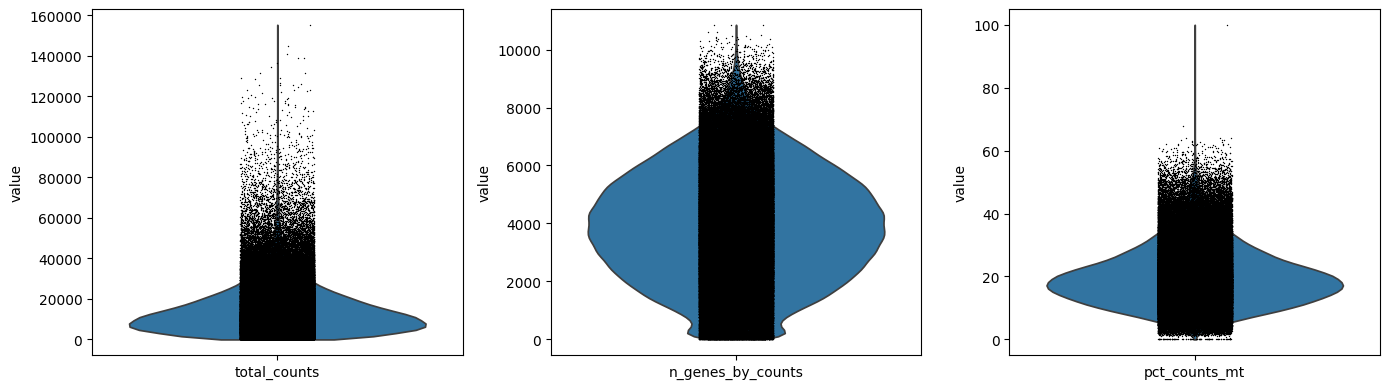

,total_counts,n_genes_by_counts,pct_counts_mt
count,232326.000000,232326.000000,232321.000000
mean,14833.030273,3942.555964,20.103832
std,11755.616211,1924.186051,9.144058
min,0.000000,0.000000,0.000000
25%,6533.000000,2499.000000,13.530475
50%,12149.000000,3914.000000,18.863964
75%,20152.000000,5328.000000,25.294733
max,155255.000000,10854.000000,100.000000


In [20]:
# Filter to in-tissue spots
adata_combined = adata_combined[adata_combined.obs["in_tissue"] == 1].copy()
print(f"Spots in tissue: {adata_combined.n_obs}")

# QC metrics
adata_combined.var["mt"] = adata_combined.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(adata_combined, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sc.pl.violin(adata_combined, "total_counts", ax=axes[0], show=False)
sc.pl.violin(adata_combined, "n_genes_by_counts", ax=axes[1], show=False)
sc.pl.violin(adata_combined, "pct_counts_mt", ax=axes[2], show=False)
plt.tight_layout()
plt.show()

adata_combined.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].describe()

## Filtering, normalization, and log-transform

In [21]:
sc.pp.filter_genes(adata_combined, min_cells=10)
sc.pp.filter_cells(adata_combined, min_counts=100)
print(f"After filtering: {adata_combined.n_obs} spots x {adata_combined.n_vars} genes")

# Store raw counts
adata_combined.layers["counts"] = adata_combined.X.copy()

# Normalize and log-transform
sc.pp.normalize_total(adata_combined, target_sum=1e4)
sc.pp.log1p(adata_combined)

After filtering: 231378 spots x 22975 genes


## HVG selection, PCA, UMAP, Leiden clustering

In [ ]:
sc.pp.highly_variable_genes(adata_combined, n_top_genes=3000, flavor="seurat", batch_key="sample")
print(f"HVGs: {adata_combined.var['highly_variable'].sum()}")

# Subset to HVGs for PCA/neighbors/clustering, but keep full object recoverable
adata_hvg = adata_combined[:, adata_combined.var["highly_variable"]].copy()

sc.tl.pca(adata_hvg, svd_solver="arpack", n_comps=50)
sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_hvg, min_dist=0.3)
sc.tl.leiden(adata_hvg, resolution=0.5, key_added="leiden_0.5")
sc.tl.leiden(adata_hvg, resolution=1.0, key_added="leiden_1.0")

# Transfer embeddings and clustering back to full object
adata_combined.obsm["X_pca"] = adata_hvg.obsm["X_pca"]
adata_combined.obsm["X_umap"] = adata_hvg.obsm["X_umap"]
adata_combined.obsp["distances"] = adata_hvg.obsp["distances"]
adata_combined.obsp["connectivities"] = adata_hvg.obsp["connectivities"]
adata_combined.obs["leiden_0.5"] = adata_hvg.obs["leiden_0.5"]
adata_combined.obs["leiden_1.0"] = adata_hvg.obs["leiden_1.0"]
adata_combined.uns["neighbors"] = adata_hvg.uns["neighbors"]
adata_combined.uns["umap"] = adata_hvg.uns["umap"]
adata_combined.uns["pca"] = adata_hvg.uns["pca"]

del adata_hvg

print(f"\n{adata_combined}")
print(f"Leiden 0.5 clusters: {adata_combined.obs['leiden_0.5'].nunique()}")
print(f"Leiden 1.0 clusters: {adata_combined.obs['leiden_1.0'].nunique()}")

HVGs: 3000


/Users/christoffer/miniconda3/envs/cellcharter310/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: divide by zero encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/christoffer/miniconda3/envs/cellcharter310/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: overflow encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/christoffer/miniconda3/envs/cellcharter310/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: invalid value encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/christoffer/miniconda3/envs/cellcharter310/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:737: RuntimeWarning: divide by zero encountered in matmul
  matmat=lambda x: X @ x - offset @ x,
/Users/christoffer/miniconda3/envs/cellcharter310/lib/python3.10/site-packages/sklearn/utils/sparsefuncs.py:737: RuntimeWarning: overflow encountered in matmul
  matmat=lambda x: X @ x - 

## Visualization

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sc.pl.umap(adata_combined, color="leiden_0.5", ax=axes[0], show=False, title="Leiden (res=0.5)")
sc.pl.umap(adata_combined, color="leiden_1.0", ax=axes[1], show=False, title="Leiden (res=1.0)")
plt.tight_layout()
plt.show()

In [ ]:
sc.pl.umap(
    adata_combined,
    color=["genotype", "age", "sex", "zeitgeber_time"],
    ncols=2,
    wspace=0.4,
)

## Save

In [ ]:
if WRITE_OUTPUT:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    adata_combined.write_h5ad(OUTPUT_PATH)
    print(f"Wrote: {OUTPUT_PATH}  ({OUTPUT_PATH.stat().st_size / 1e9:.2f} GB)")
else:
    print(f"WRITE_OUTPUT is False — set to True to save.")
    print(f"Planned output: {OUTPUT_PATH}")

Wrote: ../data/GSE282203/GSE282203_combined.h5ad  (7.36 GB)


In [ ]:
adata_combined.X.max()

np.float32(24444.0)